First of all, set the 'CODE_DIR' to where the model code are saved. This will change current working directory and print for checking. Afterwards, we import all required modules.

In [1]:
# locate the root folder
CODE_DIR = '../'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

from argparse import Namespace
import time
import sys
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as transforms

sys.path.append(".")
sys.path.append("..")

from notebooks.def_jupyt_funcs import load_pretained_ckpt, vislize_folder_imgs, transform_to_input_batch, \
    visulize_images_paired3, visulize_images_paired4, transform_to_input_image, \
    visulize_images_paired, visulize_singleImg_paired3

# from datasets import augmentations
# from utils.common import tensor2im, log_input_image
# from models.psp import pSp
# from models.stylegan2_regular import MappingNetwork_cs, MappingNetwork_cs_shared
# %load_ext autoreload
# %autoreload 2

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive


/home/ids/yuhe/anaconda3/envs/newest_pt/lib/python3.12/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/home/ids/yuhe/anaconda3/envs/newest_pt/lib/python3.12/site-packages/torch/utils/cpp_extension.py:1965: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


## Parameters setting

Fell free to change the golobal parameters for all experiments

In [2]:
EXPERIMENT_PARMS = {
    "GAN_cs_pSp_swap": { 
        #"model_path": "../pretrained_models/pSp_models/psp_ffhq_encode.pt"
        "model_path": "./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp12",
        "images_path_bg": "../eval_images/CelebAMask-HQ/female_1.jpg",
        "images_path_t": "../eval_images/CelebAMask-HQ/glass_3.jpg",
        "model_output_size" : 1024,
        "transform": transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
}

}
#/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/eval_images/CelebAMask-HQ/female_1.jpg

This experiment is to investigate the image manipulation with latent factors encoded by using the pretained model. First, we can change the parameters "experiment_type" and "img_pSp.jpg" for different experiments and different test images, respectively.

In [3]:
# setting
experiment_type = "GAN_cs_pSp_swap"
EXPERIMENT_ARGS = EXPERIMENT_PARMS[experiment_type]
model_path = EXPERIMENT_ARGS['model_path']
image_file_bg = EXPERIMENT_ARGS["images_path_bg"] 
image_file_t = EXPERIMENT_ARGS["images_path_t"]
transform = EXPERIMENT_ARGS['transform']
output_size = EXPERIMENT_ARGS['model_output_size']

model_best_pt = model_path + '/checkpoints/best_model.pt'

In [4]:
### Load the pretained pSp model
pSp_net, cs_mlp_net, opts = load_pretained_ckpt(model_best_pt, map_location = 'cpu', output_size = 1024, use_orn_pretained_pSp = True)

Loading pSp from checkpoint: ../pretrained_models/pSp_models/psp_ffhq_encode.pt
Loading cs encoder from checkpoint: ./results/opt_csmlp/netSep_mse_adam_lr001_pSploss_nmlp12/checkpoints/best_model.pt


## Load two images and Visualize them

In [5]:
image_bg = Image.open(image_file_bg)
image_t = Image.open(image_file_t)

input_image_bg = transform_to_input_image(image_bg, transform, opts)
input_image_t = transform_to_input_image(image_t, transform, opts)
# transform_to_input(original_image_A, transform, opts).unsqueeze(0)
# input_image_B = transform_to_input(original_image_B, transform, opts).unsqueeze(0)


# 

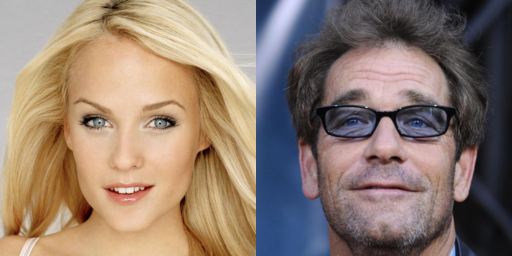

In [6]:
visulize_images_paired(input_image_bg, input_image_t, axis_dim=1)

## Image reconstruction

In [7]:


# batched_input shape: bs x 3 x w x h
with torch.no_grad():

    recon_pSp_bg, latent_pSp_bg = pSp_net.forward(input_image_bg.unsqueeze(0).to("cuda").float(), return_latents=True)
    recon_pSp_t, latent_pSp_t = pSp_net.forward(input_image_t.unsqueeze(0).to("cuda").float(), return_latents=True)

    latent_bg_c, latent_bg_s = cs_mlp_net(latent_pSp_bg)
    latent_t_c, latent_t_s = cs_mlp_net(latent_pSp_t) 

    recon_bg = pSp_net.forward(latent_bg_c, input_code=True, randomize_noise=True, recon_modle=True)
    recon_t = pSp_net.forward(latent_t_c + latent_t_s, input_code=True, randomize_noise=True, recon_modle=True)	
    
    recon_bg_swap = pSp_net.forward(latent_bg_c + latent_t_s, input_code=True, randomize_noise=True, recon_modle=True)
    recon_t_swap = pSp_net.forward(latent_t_c, input_code=True, randomize_noise=True, recon_modle=True)	

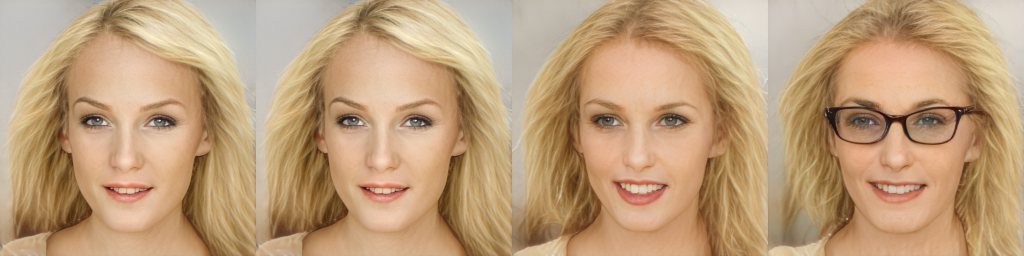

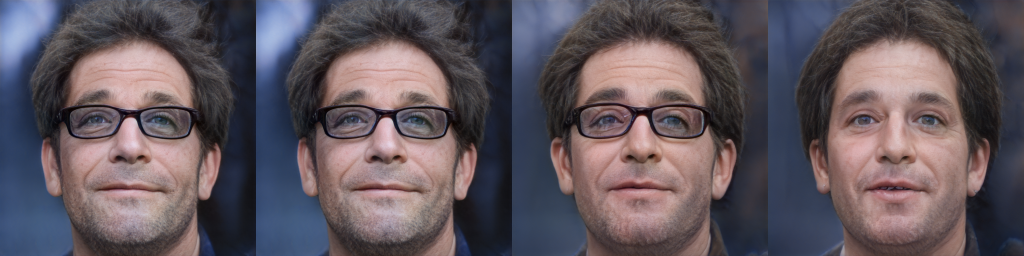

In [8]:
visulize_images_paired4(input_image_bg.unsqueeze(0), recon_pSp_bg, recon_bg, recon_bg_swap)
visulize_images_paired4(input_image_t.unsqueeze(0), recon_pSp_t, recon_t, recon_t_swap)